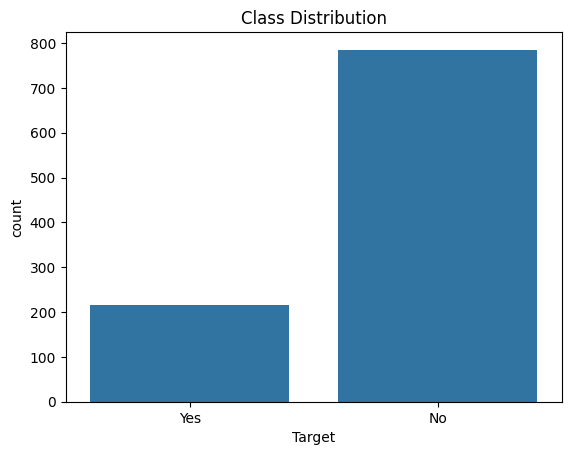

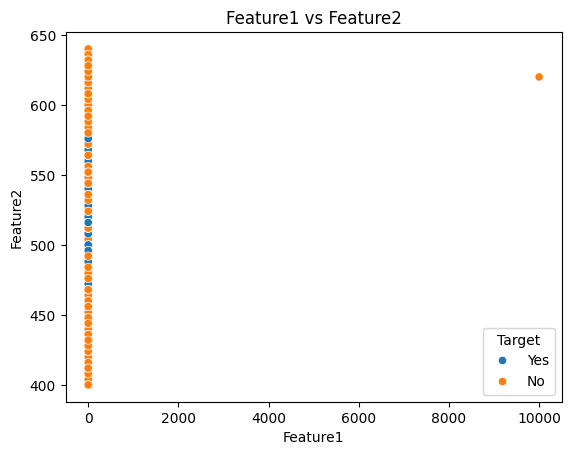

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/Lab_Exam_binary_classification_dataset.csv")

df.head()
df.isnull().sum()
sns.countplot(x="Target", data=df)
plt.title("Class Distribution")
plt.show()
sns.scatterplot(x="Feature1", y="Feature2", hue="Target", data=df)

plt.title("Feature1 vs Feature2")
plt.show()


In [32]:
df = df[df["Feature1"] < 1000]
# Drop rows with NaN values in the target column and update df
df = df.dropna(subset=[df.columns[-1]])
df["Target"].value_counts()

,count
Target,
No,784
Yes,215


In [34]:
from sklearn.utils import resample

# Separate classes using numerical labels
df_majority = df[df.Target == 'No']
df_minority = df[df.Target == 'Yes']

# Oversample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority), # Use the actual size of the majority class
    random_state=42
)

# Combine datasets
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Check new distribution
df_balanced["Target"].value_counts()

,count
Target,
No,784
Yes,784


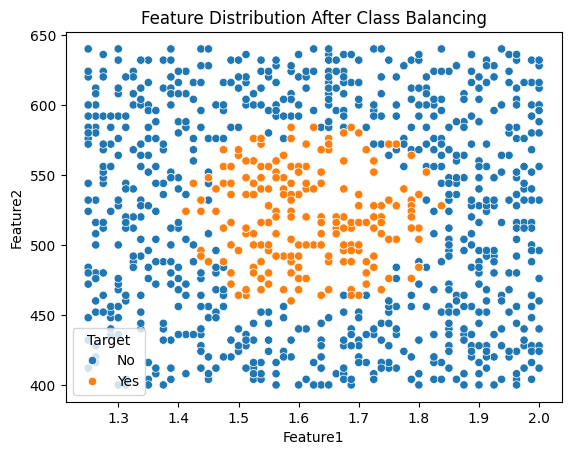

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="Feature1",
    y="Feature2",
    hue="Target",
    data=df_balanced
)

plt.title("Feature Distribution After Class Balancing")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(class_weight='balanced')

# Check if y_train contains NaN values and clean if necessary
if y_train.isnull().any():
    print("Warning: y_train contains NaN values. Removing them and corresponding X_train rows.")
    # Get boolean mask for non-null values in y_train
    valid_indices = ~y_train.isnull()

    # Filter X_train (numpy array) using the boolean mask
    X_train_clean = X_train[valid_indices.values]
    # Filter y_train (pandas Series) by dropping NaNs
    y_train_clean = y_train.dropna()
else:
    # If no NaNs, use the original X_train and y_train
    X_train_clean = X_train
    y_train_clean = y_train

model.fit(X_train_clean, y_train_clean)

LogisticRegression(class_weight='balanced')

In [37]:
df["Target"] = df["Target"].map({"No":0, "Yes":1})

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check if y_test contains NaN values and clean if necessary
if y_test.isnull().any():
    print("Warning: y_test contains NaN values. Removing them and corresponding X_test rows.")
    # Get boolean mask for non-null values in y_test
    valid_indices_test = ~y_test.isnull()

    # Filter X_test (numpy array) using the boolean mask
    X_test_clean = X_test[valid_indices_test.values]
    # Filter y_test (pandas Series) by dropping NaNs
    y_test_clean = y_test.dropna()
else:
    # If no NaNs, use the original X_test and y_test
    X_test_clean = X_test
    y_test_clean = y_test

# Recalculate y_pred to ensure it's up-to-date and consistent with X_test_clean
y_pred = model.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test_clean, y_pred))
print(confusion_matrix(y_test_clean, y_pred))
print(classification_report(y_test_clean, y_pred))

Accuracy: 0.45
[[ 43 110]
 [  0  47]]
              precision    recall  f1-score   support

          No       1.00      0.28      0.44       153
         Yes       0.30      1.00      0.46        47

    accuracy                           0.45       200
   macro avg       0.65      0.64      0.45       200
weighted avg       0.84      0.45      0.44       200



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


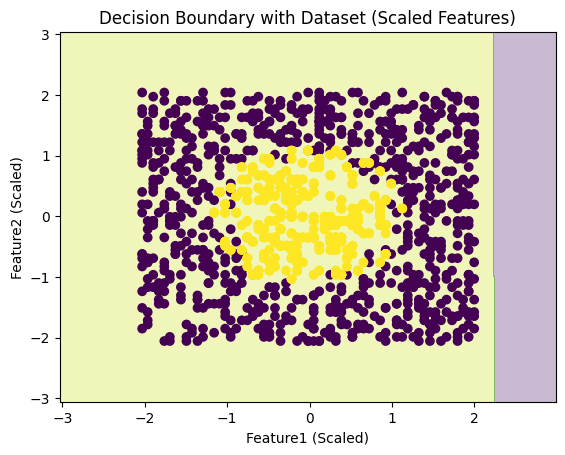

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder, StandardScaler # Import LabelEncoder and StandardScaler
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Re-create df based on the state before balancing from cell EnEduzOpnROW
df = pd.read_csv("/Lab_Exam_binary_classification_dataset.csv")

# Re-apply cleaning from cell 7YTiNP9BncMJ
df = df[df["Feature1"] < 1000]
df = df.dropna(subset=[df.columns[-1]])

# Re-create df_balanced from cell RxM5upZZnoy8
df_majority = df[df.Target == 'No']
df_minority = df[df.Target == 'Yes']
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Define X and y from the balanced dataframe
X = df_balanced[['Feature1', 'Feature2']]
y = df_balanced['Target']

# Convert target labels 'No'/'Yes' to 0/1 for model training, similar to WMHINTIwoCsI
y = y.map({"No":0, "Yes":1})

# Perform train-test split (similar to ph-jPBLwn0at)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply StandardScaler (similar to ph-jPBLwn0at)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model (similar to BxACtLvrn9kS)
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Now, for plotting, scale the full X before creating mesh grid
# This ensures X_set is on the same scale as X_train_scaled used for model fitting
X_scaled_for_plot = scaler.transform(X)

# Convert features to numpy arrays (using scaled X)
X_set = X_scaled_for_plot
y_set = y.values # y is already mapped to 0/1

# Initialize LabelEncoder (needed if y_set was not numerical, but here it is 0/1)
# If y_set is already 0/1, le.fit_transform might not be strictly necessary, but good for consistency
le = LabelEncoder()
y_set_encoded = y_set # Since y is already 0/1

# Create mesh grid using the scaled feature ranges
X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

# Predict for every point in grid
# Need to scale the meshgrid points before prediction
Z_predictions_1d = model.predict(scaler.transform(np.array([X1.ravel(), X2.ravel()]).T))

# Z is already numerical (0s and 1s) from model.predict
Z = Z_predictions_1d.reshape(X1.shape).astype(float)

# Plot decision boundary
plt.contourf(X1, X2, Z, alpha=0.3)

# Plot original data points using encoded y_set
plt.scatter(X_set[:,0], X_set[:,1], c=y_set_encoded)

plt.xlabel("Feature1 (Scaled)") # Update label to reflect scaling
plt.ylabel("Feature2 (Scaled)") # Update label to reflect scaling
plt.title("Decision Boundary with Dataset (Scaled Features)")

plt.show()